# Set 11 - Hierarchisches Clustering, DBSCAN und GMM

Ein einziges Clusterverfahren passt nicht zu jeder Geometrie. Wir vergleichen harte zentrumsbasierte Gruppen, hierarchische Verschmelzung, dichtebasierte Cluster und probabilistisches Soft-Clustering.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Gekrümmte Cluster und einzelne Störpunkte

Zwei Monde verletzen die Kugelannahme von K-Means. Zusätzliche, gleichmäßig verteilte Punkte simulieren Noise. Die bekannten Farben im ersten Plot dienen nur zur Orientierung.


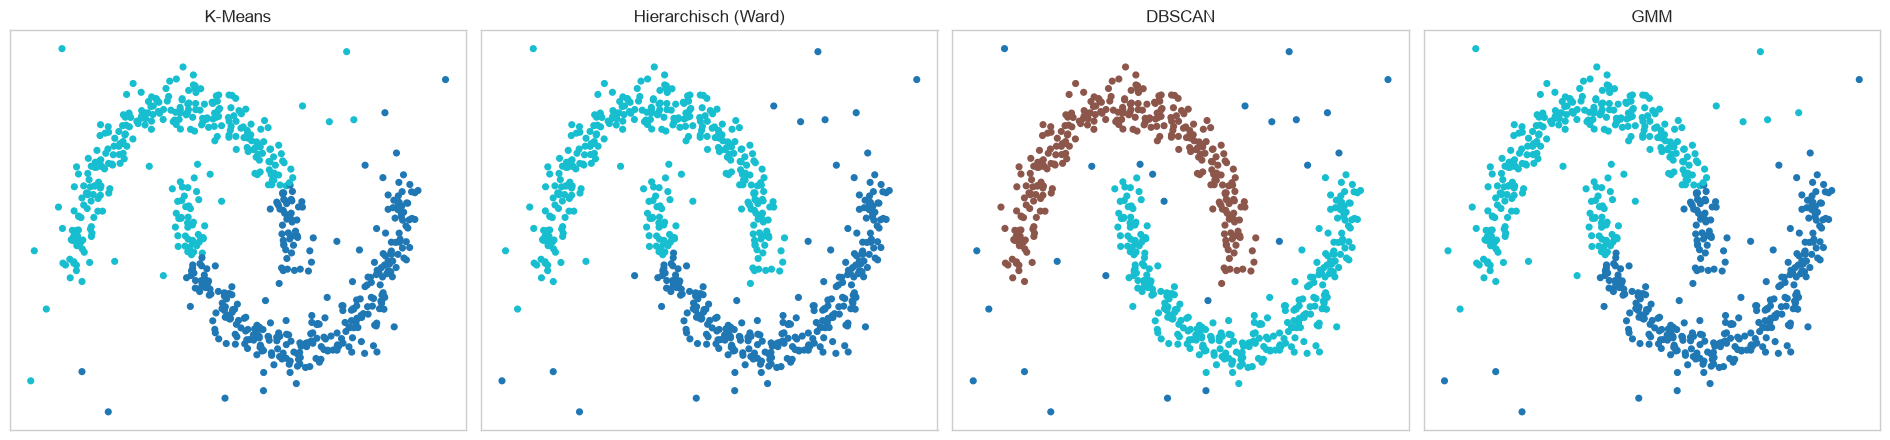

,Verfahren,Gefundene Cluster,Noise-Punkte
0,K-Means,2,0
1,Hierarchisch (Ward),2,0
2,DBSCAN,2,24
3,GMM,2,0


In [2]:
X_moons, hidden_groups = make_moons(
    n_samples=620, noise=0.075, random_state=RANDOM_STATE
)
noise_points = rng.uniform(low=[-1.5, -0.9], high=[2.5, 1.4], size=(45, 2))
X = np.vstack([X_moons, noise_points])
X_scaled = StandardScaler().fit_transform(X)

algorithms = {
    "K-Means": KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE),
    "Hierarchisch (Ward)": AgglomerativeClustering(n_clusters=2, linkage="ward"),
    "DBSCAN": DBSCAN(eps=0.22, min_samples=8),
    "GMM": GaussianMixture(n_components=2, covariance_type="full", random_state=RANDOM_STATE),
}

labels = {}
for name, model in algorithms.items():
    labels[name] = model.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, (name, predicted) in zip(axes, labels.items()):
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=predicted, cmap="tab10", s=17)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

summary = []
for name, predicted in labels.items():
    cluster_ids = set(predicted) - {-1}
    summary.append({
        "Verfahren": name,
        "Gefundene Cluster": len(cluster_ids),
        "Noise-Punkte": int(np.sum(predicted == -1)),
    })
display(pd.DataFrame(summary))


K-Means und GMM müssen jeden Punkt zuordnen. DBSCAN kann Noise explizit markieren und gekrümmte Formen verbinden. Hierarchisches Clustering liefert zunächst eine Verschmelzungshierarchie; die endgültige Clusterzahl entsteht durch einen Schnitt.


## 2. Dendrogramm als Hierarchie

Für die Lesbarkeit verwenden wir eine Stichprobe. Die Höhe einer Verbindung zeigt, bei welcher Distanz zwei Teilcluster verschmelzen. Ein horizontaler Schnitt durch den Baum bestimmt eine mögliche Clusterzahl.


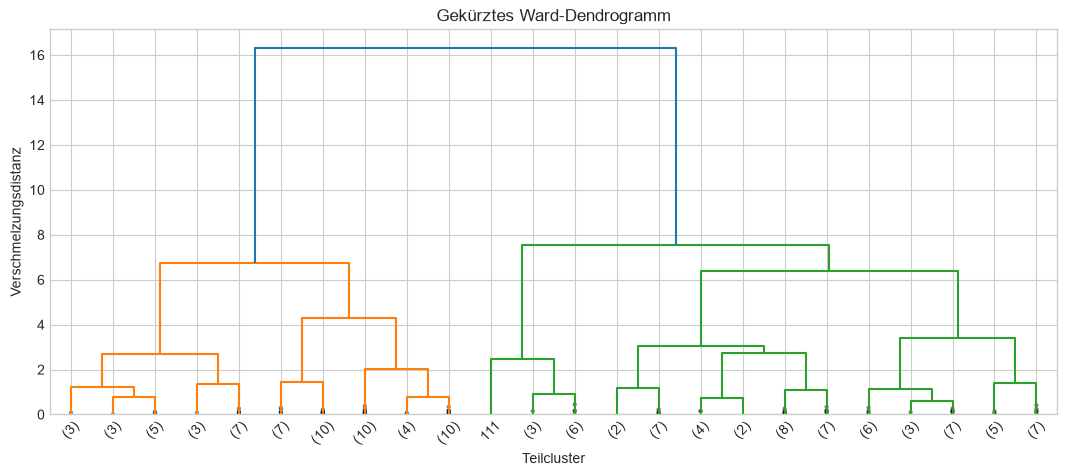

In [3]:
sample_ids = rng.choice(len(X_scaled), size=130, replace=False)
linkage_matrix = linkage(X_scaled[sample_ids], method="ward")

plt.figure(figsize=(13, 5))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=24,
    show_contracted=True,
    leaf_rotation=45,
)
plt.xlabel("Teilcluster"); plt.ylabel("Verschmelzungsdistanz")
plt.title("Gekürztes Ward-Dendrogramm")
plt.show()


## 3. DBSCAN reagiert empfindlich auf eps

eps definiert die Nachbarschaftsgröße, min_samples die Mindestdichte. Ein zu kleines eps produziert viele Noise-Punkte, ein zu großes eps kann getrennte Strukturen verbinden.


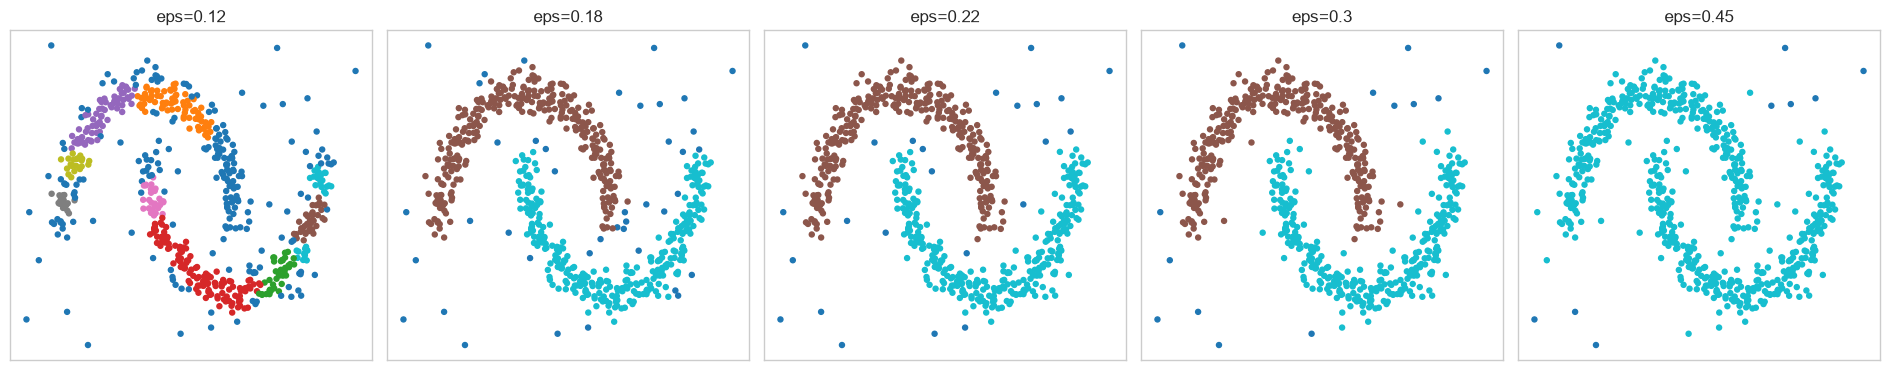

,eps,Cluster,Noise
0,0.12,13,155
1,0.18,2,41
2,0.22,2,24
3,0.30,2,13
4,0.45,1,9


In [4]:
eps_values = [0.12, 0.18, 0.22, 0.30, 0.45]
rows = []
fig, axes = plt.subplots(1, len(eps_values), figsize=(19, 3.8))

for ax, eps in zip(axes, eps_values):
    predicted = DBSCAN(eps=eps, min_samples=8).fit_predict(X_scaled)
    n_clusters = len(set(predicted) - {-1})
    n_noise = int(np.sum(predicted == -1))
    rows.append({"eps": eps, "Cluster": n_clusters, "Noise": n_noise})
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=predicted, cmap="tab10", s=13)
    ax.set_title(f"eps={eps}"); ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()
display(pd.DataFrame(rows))


## 4. GMM für elliptische Cluster und Soft-Zuordnungen

Nun erzeugen wir Daten, die tatsächlich aus mehreren Gauß-Verteilungen stammen. Anders als K-Means modelliert ein GMM Mittelwerte, Kovarianzen und Mischungsgewichte. Es liefert für jeden Punkt Zugehörigkeitswahrscheinlichkeiten.


,K,BIC,AIC
0,1,7026.8,7003.5
1,2,5936.7,5885.5
2,3,5453.9,5374.7
3,4,5490.6,5383.4
4,5,5528.0,5392.9
5,6,5569.4,5406.3


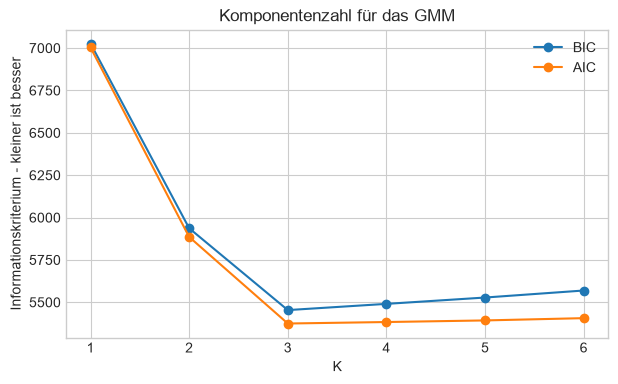

In [5]:
means = [(-3, -1), (0.5, 2.5), (3.2, -1.2)]
covariances = [
    [[1.2, 0.8], [0.8, 0.8]],
    [[0.45, -0.25], [-0.25, 1.2]],
    [[0.9, 0.1], [0.1, 0.35]],
]
sizes = [280, 240, 260]
X_elliptic = np.vstack([
    rng.multivariate_normal(mean, covariance, size)
    for mean, covariance, size in zip(means, covariances, sizes)
])

criteria = []
models = {}
for k in range(1, 7):
    model = GaussianMixture(
        n_components=k, covariance_type="full",
        n_init=5, random_state=RANDOM_STATE
    ).fit(X_elliptic)
    models[k] = model
    criteria.append({"K": k, "BIC": model.bic(X_elliptic), "AIC": model.aic(X_elliptic)})

criteria = pd.DataFrame(criteria)
display(criteria.round(1))
criteria.plot(x="K", y=["BIC", "AIC"], marker="o", figsize=(7, 4))
plt.ylabel("Informationskriterium - kleiner ist besser")
plt.title("Komponentenzahl für das GMM")
plt.show()


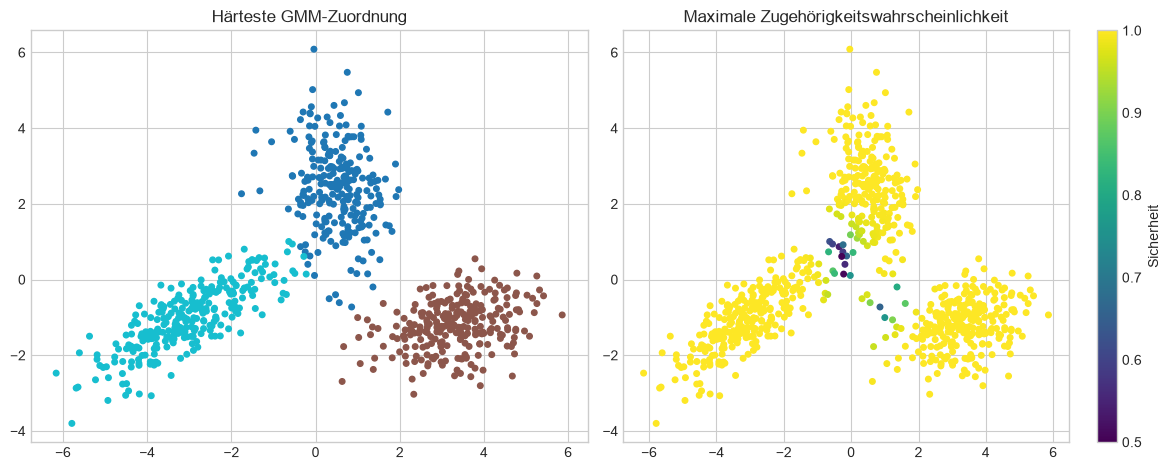

,P(Cluster 0),P(Cluster 1),P(Cluster 2)
0,0.497,0.00,0.503
1,0.491,0.00,0.509
2,0.542,0.00,0.458
3,0.560,0.00,0.440
4,0.583,0.00,0.417
5,0.400,0.00,0.600
6,0.378,0.00,0.622
7,0.660,0.34,0.000


In [6]:
gmm = models[3]
probabilities = gmm.predict_proba(X_elliptic)
assignments = probabilities.argmax(axis=1)
certainty = probabilities.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(
    X_elliptic[:, 0], X_elliptic[:, 1],
    c=assignments, cmap="tab10", s=16
)
axes[0].set_title("Härteste GMM-Zuordnung")
points = axes[1].scatter(
    X_elliptic[:, 0], X_elliptic[:, 1],
    c=certainty, cmap="viridis", vmin=0.5, vmax=1, s=16
)
axes[1].set_title("Maximale Zugehörigkeitswahrscheinlichkeit")
fig.colorbar(points, ax=axes[1], label="Sicherheit")
plt.tight_layout(); plt.show()

uncertain = np.argsort(certainty)[:8]
display(pd.DataFrame(
    probabilities[uncertain],
    columns=["P(Cluster 0)", "P(Cluster 1)", "P(Cluster 2)"]
).round(3))


## Fazit

- Hierarchisches Clustering macht Verschmelzungen und alternative Schnitte sichtbar.
- DBSCAN braucht keine feste Clusterzahl, findet beliebige Formen und markiert Noise, ist aber skalen- und parameterempfindlich.
- GMM modelliert elliptische Verteilungen und liefert weiche Zugehörigkeiten.
- K-Means ist einfach und schnell, aber auf zentrumsnahe, kompakte Cluster zugeschnitten.
- Noise bei DBSCAN und geringe GMM-Dichte sind mögliche Brücken zur Anomalieerkennung, aber noch keine fachlich bestätigten Anomalien.
